In [1]:
                                # Run this cell once to install all required packages
import subprocess, sys

packages = ['faker', 'pandas', 'numpy', 'tqdm', 'matplotlib', 'seaborn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed successfully')

All packages installed successfully


In [2]:
import uuid
import random
import hashlib
import base64
import csv
import json
import os
import time
import warnings
from datetime import datetime, timedelta
from multiprocessing import Pool, cpu_count
from functools import partial

import numpy as np
import pandas as pd
from faker import Faker
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
fake = Faker()
Faker.seed(42)
random.seed(42)
np.random.seed(42)

print(f'Imports complete | CPUs available: {cpu_count()}')

Imports complete | CPUs available: 12


In [3]:

#  CONFIGURATION  — Adjust these values as needed


CONFIG = {
    'NUM_RECORDS'        : 100_000,   # Total records to generate
    'OUTPUT_FILE'        : 'email_security_dataset.csv',
    'USE_MULTIPROCESSING': True,      # Set False if issues arise
    'CHUNK_SIZE'         : 10_000,    # Records per chunk

    # Label distribution
    'LABEL_DIST': {
        'legitimate': 0.60,   # 60,000 records
        'spam'      : 0.25,   # 25,000 records
        'phishing'  : 0.15,   # 15,000 records
    },

    # Data source mix (must sum to 1.0)
    'SOURCE_DIST': {
        'synthetic'    : 0.75,  # Pure synthetic
        'enron_style'  : 0.15,  # ENRON-inspired (corporate email style)
        'spam_style'   : 0.06,  # SpamAssassin-inspired
        'phish_style'  : 0.04,  # Nazario-inspired phishing
    },
}


#  DOMAIN POOLS


LEGITIMATE_DOMAINS = [
    'gmail.com', 'yahoo.com', 'outlook.com', 'hotmail.com',
    'company.com', 'enterprise.org', 'corporate.net', 'business.io',
    'university.edu', 'gov.org', 'microsoft.com', 'apple.com',
    'amazon.com', 'salesforce.com', 'adobe.com', 'ibm.com',
    'oracle.com', 'cisco.com', 'intel.com', 'hp.com',
]

PHISHING_DOMAINS = [
    'g00gle.com', 'paypa1.com', 'secure-login.xyz', 'amazon-verify.ru',
    'microsoft-alert.tk', 'bankofamerica-secure.ml', 'apple-id-verify.gq',
    'account-update.info', 'login-secure.pw', 'verify-account.cc',
    'support-helpdesk.xyz', 'noreply-security.tk', 'urgent-action.ml',
    'account-suspended.gq', 'security-alert.pw',
]

SPAM_DOMAINS = [
    'offers-today.com', 'deals-unlimited.net', 'promo-blast.org',
    'newsletter-hub.com', 'marketing-pro.net', 'bulk-mailer.com',
    'cheapmeds.biz', 'lottowin.info', 'forex-profits.com',
    'diet-miracle.net', 'work-from-home.biz', 'free-iphone.win',
]

CORPORATE_DOMAINS = [
    'enron.com', 'worldcom.net', 'lehman.com', 'tyco.org',
    'xerox.com', 'boeing.com', 'ge.com', 'ford.com',
    'caterpillar.com', 'honeywell.com',
]


#  DKIM / MAILER POOLS


DKIM_SELECTORS   = ['selector1','selector2','default','mail','dkim2024',
                    'google','s1','s2','k1','mimecast','proofpoint']
DKIM_ALGORITHMS  = ['rsa-sha256','rsa-sha256','rsa-sha256','rsa-sha1','ed25519-sha256']
CANONICALIZATION = ['relaxed/relaxed','relaxed/simple','simple/relaxed','simple/simple']

MAILERS = [
    'Postfix 3.6.7', 'Sendmail 8.15.2', 'Microsoft SMTP Server v15.0',
    'Exim 4.96', 'Mimecast SMTP', 'Proofpoint Essentials',
    'Google Gmail', 'Yahoo Mail', 'Outlook 16.0', 'Thunderbird 115.0',
    'MailChimp Mandrill', 'SendGrid', 'Amazon SES',
]

SPAM_MAILERS = [
    'PHPMailer 5.2', 'Bulk Email Pro 2.1', 'Unknown',
    'MailBomber 3.0', 'MassMail 7.2', 'SpamBot v1.0',
]


#  ATTACK PATTERNS (for security research annotations)


ATTACK_PATTERNS = [
    'display_name_spoofing',
    'lookalike_domain',
    'subdomain_abuse',
    'reply_to_hijack',
    'dkim_replay_attack',
    'spf_none_exploit',
    'dmarc_none_policy_abuse',
    'header_injection',
    'multi_hop_obfuscation',
    'cousin_domain',
    'homograph_attack',
    'open_redirect_url',
    'none',  # Most spam/phish will have this as fallback
]

print(' Configuration loaded')
print(f"   Total records    : {CONFIG['NUM_RECORDS']:,}")
print(f"   Legitimate       : {int(CONFIG['NUM_RECORDS'] * CONFIG['LABEL_DIST']['legitimate']):,}")
print(f"   Spam             : {int(CONFIG['NUM_RECORDS'] * CONFIG['LABEL_DIST']['spam']):,}")
print(f"   Phishing         : {int(CONFIG['NUM_RECORDS'] * CONFIG['LABEL_DIST']['phishing']):,}")

 Configuration loaded
   Total records    : 100,000
   Legitimate       : 60,000
   Spam             : 25,000
   Phishing         : 15,000


In [4]:

#  HELPER UTILITIES


def random_public_ip():
    """Generate a random public IPv4 address (avoids private ranges)"""
    while True:
        ip = f"{random.randint(1,254)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}"
        first = int(ip.split('.')[0])
        if first not in (10, 127, 172, 192, 169):
            return ip

def random_private_ip():
    """Generate a random private IPv4 address"""
    return f"192.168.{random.randint(0,255)}.{random.randint(1,254)}"

def fake_base64_hash(length=44):
    """Generate a realistic base64 hash (simulates DKIM body hash / signature)"""
    raw = base64.b64encode(hashlib.sha256(uuid.uuid4().bytes).digest()).decode()
    return raw[:length]

def fake_long_signature(length=88):
    """Generate a realistic long base64 DKIM signature block"""
    combined = ''
    while len(combined) < length:
        combined += base64.b64encode(hashlib.sha256(uuid.uuid4().bytes).digest()).decode()
    return combined[:length]

def random_message_id(domain):
    """Generate a realistic Message-ID header value"""
    ts = datetime.utcnow().strftime('%Y%m%d%H%M%S')
    uid = uuid.uuid4().hex[:12]
    return f"<{ts}.{uid}@{domain}>"

def random_date(days_back=730):
    """Generate a random date within the past N days"""
    delta = timedelta(
        days=random.randint(0, days_back),
        hours=random.randint(0, 23),
        minutes=random.randint(0, 59),
        seconds=random.randint(0, 59)
    )
    dt = datetime.utcnow() - delta
    return dt.strftime("%a, %d %b %Y %H:%M:%S +0000")

def make_hostname(domain=None):
    """Generate a realistic mail server hostname"""
    prefixes = ['mail', 'smtp', 'mx', 'relay', 'outbound', 'send', 'mta']
    if domain:
        return f"{random.choice(prefixes)}.{domain}"
    return f"{random.choice(prefixes)}{random.randint(1,9)}.{fake.domain_name()}"

print(' Helper functions defined')

 Helper functions defined


In [6]:

#  SPF GENERATOR


def generate_spf(label, sender_domain, client_ip):
    """
    Generate realistic SPF fields.
    Legitimate email: mostly pass
    Spam: mix of softfail/neutral
    Phishing: mostly fail/none
    """
    weights = {
        'legitimate': {'pass':0.85, 'neutral':0.08, 'softfail':0.04, 'none':0.02, 'fail':0.01},
        'spam'      : {'pass':0.30, 'neutral':0.20, 'softfail':0.30, 'none':0.12, 'fail':0.08},
        'phishing'  : {'pass':0.10, 'neutral':0.10, 'softfail':0.25, 'none':0.20, 'fail':0.35},
    }
    w = weights[label]
    result = random.choices(list(w.keys()), weights=list(w.values()))[0]

    permitted = result == 'pass'
    receiver  = f"mx.{fake.domain_name()}"

    raw = (
        f"{result} ({receiver}: domain of {sender_domain} "
        f"designates {client_ip} as {'permitted' if permitted else 'not permitted'} sender) "
        f"receiver={receiver}; client-ip={client_ip}; "
        f"helo={make_hostname(sender_domain)};"
    )
    return result, sender_domain, client_ip, raw


#  DKIM GENERATOR


def generate_dkim(label, sender_domain):
    """
    Generate realistic DKIM fields.
    """
    weights = {
        'legitimate': {'pass':0.88, 'none':0.07, 'fail':0.03, 'temperror':0.02},
        'spam'      : {'pass':0.25, 'none':0.35, 'fail':0.30, 'temperror':0.10},
        'phishing'  : {'pass':0.08, 'none':0.30, 'fail':0.50, 'temperror':0.12},
    }
    w = weights[label]
    result   = random.choices(list(w.keys()), weights=list(w.values()))[0]
    selector = random.choice(DKIM_SELECTORS)
    algo     = random.choice(DKIM_ALGORITHMS)
    canon    = random.choice(CANONICALIZATION)
    headers  = 'from:to:subject:date:message-id:mime-version:content-type'
    body_hash = fake_base64_hash(44)
    signature = fake_long_signature(88)

    if result == 'pass':
        raw = (
            f"v=1; a={algo}; c={canon}; d={sender_domain}; s={selector}; "
            f"h={headers}; bh={body_hash}; "
            f"b={signature}"
        )
    else:
        raw = 'none'

    return result, sender_domain, selector, algo, raw


#  DMARC GENERATOR

def generate_dmarc(label, spf_result, dkim_result, sender_domain):
    """
    DMARC result is derived from SPF + DKIM alignment.
    Pass requires at least one of SPF or DKIM to pass AND align.
    """
    spf_pass  = spf_result  == 'pass'
    dkim_pass = dkim_result == 'pass'

    # Alignment simulation
    if label == 'legitimate':
        spf_align  = spf_pass  and random.random() > 0.05
        dkim_align = dkim_pass and random.random() > 0.05
    elif label == 'spam':
        spf_align  = spf_pass  and random.random() > 0.50
        dkim_align = dkim_pass and random.random() > 0.50
    else:  # phishing
        spf_align  = spf_pass  and random.random() > 0.80
        dkim_align = dkim_pass and random.random() > 0.80

    dmarc_pass = spf_align or dkim_align

    policy_weights = {
        'legitimate': {'none':0.30, 'quarantine':0.40, 'reject':0.30},
        'spam'      : {'none':0.50, 'quarantine':0.35, 'reject':0.15},
        'phishing'  : {'none':0.60, 'quarantine':0.25, 'reject':0.15},
    }
    pw = policy_weights[label]
    policy = random.choices(list(pw.keys()), weights=list(pw.values()))[0]

    result = 'pass' if dmarc_pass else random.choice(['fail','quarantine','reject'])

    return (
        result, policy,
        'pass' if spf_align  else 'fail',
        'pass' if dkim_align else 'fail',
    )



#  ARC GENERATOR


def generate_arc(label, spf_result, dkim_result, dmarc_result, sender_domain):
    """
    ARC (Authenticated Received Chain) — used in email forwarding scenarios.
    """
    cv_weights = {
        'legitimate': {'none':0.60, 'pass':0.35, 'fail':0.05},
        'spam'      : {'none':0.40, 'pass':0.20, 'fail':0.40},
        'phishing'  : {'none':0.30, 'pass':0.10, 'fail':0.60},
    }
    cv_w = cv_weights[label]
    cv   = random.choices(list(cv_w.keys()), weights=list(cv_w.values()))[0]
    algo = random.choice(DKIM_ALGORITHMS)

    arc_seal = (
        f"i=1; a={algo}; cv={cv}; d=google.com; "
        f"s=arc-20160816; b={fake_long_signature(88)}"
    )
    arc_msg_sig = (
        f"i=1; a={algo}; c=relaxed/relaxed; d={sender_domain}; "
        f"s=arc-20160816; h=mime-version:from:date:message-id:subject:to; "
        f"bh={fake_base64_hash(44)}; b={fake_long_signature(88)}"
    )
    arc_auth = (
        f"i=1; mx.google.com; "
        f"dkim={dkim_result} header.i=@{sender_domain}; "
        f"spf={spf_result} smtp.mailfrom={sender_domain}; "
        f"dmarc={dmarc_result} header.from={sender_domain}"
    )
    return arc_seal, arc_msg_sig, arc_auth



#  RECEIVED CHAIN (Routing Hops) GENERATOR


def generate_received_chain(label, sender_domain, num_hops=None):
    """
    Generate a realistic Received: header chain.
    Phishing emails may inject suspicious relay hops.
    """
    if num_hops is None:
        hop_weights = {
            'legitimate': [0.10, 0.40, 0.35, 0.10, 0.05],  # 1-5 hops
            'spam'      : [0.05, 0.20, 0.35, 0.25, 0.15],
            'phishing'  : [0.02, 0.10, 0.30, 0.33, 0.25],
        }
        num_hops = random.choices(range(1, 6), weights=hop_weights[label])[0]

    chain = []
    protocols = ['ESMTPS', 'ESMTP', 'SMTP', 'ESMTPSA']

    for i in range(num_hops):
        src_host  = make_hostname(sender_domain if i == 0 else None)
        src_ip    = random_private_ip() if i == 0 else random_public_ip()
        dst_host  = f"mx{i+1}.{fake.domain_name()}"
        proto     = random.choice(protocols)
        hop_id    = uuid.uuid4().hex[:12]
        ts        = (datetime.utcnow() - timedelta(minutes=(num_hops - i) * 3)
                     ).strftime("%a, %d %b %Y %H:%M:%S +0000")

        hop = (
            f"from {src_host} ({src_host} [{src_ip}]) "
            f"by {dst_host} with {proto} id {hop_id}; {ts}"
        )
        chain.append(hop)

    # Inject suspicious relay for phishing
    if label == 'phishing' and random.random() > 0.40:
        phish_host = f"relay.{random.choice(PHISHING_DOMAINS)}"
        phish_ip   = random_public_ip()
        suspicious_hop = (
            f"from {phish_host} (EHLO {phish_host}) [{phish_ip}] "
            f"by anonymous-relay.net with SMTP; "
            f"{(datetime.utcnow() - timedelta(minutes=8)).strftime('%a, %d %b %Y %H:%M:%S +0000')}"
        )
        chain.insert(1, suspicious_hop)

    return ' || '.join(chain), len(chain)


print('Security header generators defined')

Security header generators defined


In [7]:
#  EMAIL CONTENT STYLE GENERATORS
#  These simulate the writing/domain style of real datasets
#  without using any real data


ENRON_SUBJECTS = [
    'Re: Meeting tomorrow', 'FW: Q{q} Results', 'Action Required: Budget Review',
    'Project Update - {project}', 'Re: {name} - follow up',
    'Fw: Contract Amendment', 'Urgent: Board Approval Needed',
    'Quarterly Earnings Call', 'Re: Deal with {company}',
    'Please review attached', 'Schedule for next week', 'Re: Your voicemail',
]

SPAM_SUBJECTS = [
    'You\'ve WON $1,000,000!', 'Lose 30lbs in 30 days GUARANTEED',
    'URGENT: Your account needs verification',
    'Make $5000/week from home!!', 'Hot singles in your area',
    'Cheap Rx Medications — No Prescription Needed',
    'Limited Time Offer — 90% OFF', 'RE: Your loan application approved',
    'FREE iPhone 15 Pro — Claim Now', 'Viagra & Cialis — Lowest Price',
    'Investment Opportunity — 300% Returns', 'You have a pending payment',
]

PHISH_SUBJECTS = [
    'Your {brand} account has been suspended',
    'Action Required: Verify your {brand} account',
    'Unusual sign-in activity on your account',
    'Your {brand} password will expire today',
    'Security Alert: New login from unknown device',
    'Invoice #{num} Payment Overdue',
    'Your {brand} account has been locked',
    'Please confirm your identity',
    'DocuSign: Document ready for signature',
    'DHL: Your package could not be delivered',
    'IRS: Tax refund pending — Action Required',
    'Your {brand} subscription is expiring',
]

BRANDS = ['PayPal', 'Amazon', 'Microsoft', 'Apple', 'Netflix', 'Bank of America',
          'Chase', 'Wells Fargo', 'Google', 'Facebook', 'Instagram', 'DHL', 'FedEx']


def get_subject(label, data_source):
    if label == 'legitimate' or data_source == 'enron_style':
        tmpl = random.choice(ENRON_SUBJECTS)
        return tmpl.format(
            q=random.randint(1,4), name=fake.first_name(),
            project=fake.bs().title(), company=fake.company()
        )
    elif label == 'spam' or data_source == 'spam_style':
        return random.choice(SPAM_SUBJECTS)
    else:  # phishing
        tmpl = random.choice(PHISH_SUBJECTS)
        return tmpl.format(
            brand=random.choice(BRANDS),
            num=random.randint(10000, 99999)
        )


def get_domains_for_label(label, data_source):
    """Return (sender_domain, envelope_domain) pair based on label"""
    if label == 'legitimate':
        if data_source == 'enron_style':
            d = random.choice(CORPORATE_DOMAINS)
        else:
            d = random.choice(LEGITIMATE_DOMAINS)
        return d, d  # aligned
    elif label == 'spam':
        sd = random.choice(SPAM_DOMAINS)
        # Spam may or may not align envelope
        ed = sd if random.random() > 0.40 else random.choice(SPAM_DOMAINS)
        return sd, ed
    else:  # phishing
        # Header From often spoofs a legit brand, envelope is phish domain
        header_domain = random.choice(PHISHING_DOMAINS)
        envelope_domain = random.choice(PHISHING_DOMAINS)
        return header_domain, envelope_domain


def get_attack_pattern(label, spf_result, dkim_result, dmarc_result,
                        header_domain, envelope_domain):
    """Annotate the primary attack pattern used (for security research)"""
    if label == 'legitimate':
        return 'none'

    patterns = []
    if header_domain != envelope_domain:
        patterns.append('display_name_spoofing')
    if any(c.isdigit() for c in header_domain.split('.')[0]):
        patterns.append('lookalike_domain')
    if header_domain.count('.') >= 3:
        patterns.append('subdomain_abuse')
    if spf_result  == 'none':
        patterns.append('spf_none_exploit')
    if dmarc_result == 'none' or dmarc_result == 'pass':
        patterns.append('dmarc_none_policy_abuse')
    if dkim_result == 'pass' and spf_result == 'fail':
        patterns.append('dkim_replay_attack')

    return random.choice(patterns) if patterns else random.choice(ATTACK_PATTERNS[:-1])


print('Email style generators defined')

Email style generators defined


In [8]:

#  MASTER RECORD GENERATOR


def generate_record(label, data_source='synthetic'):
    """
    Generate a single email security header record.

    Parameters
    ----------
    label       : str  — 'legitimate', 'spam', or 'phishing'
    data_source : str  — 'synthetic', 'enron_style', 'spam_style', 'phish_style'

    Returns
    -------
    dict with all 35+ fields
    """

    # ── Domains 
    header_domain, envelope_domain = get_domains_for_label(label, data_source)
    sender_user  = fake.user_name()
    sender_email = f"{sender_user}@{header_domain}"
    rcpt_email   = fake.email()

    # Return-Path uses envelope domain
    return_path  = f"<{sender_user}@{envelope_domain}>"

    # Reply-To: phishing often uses different domain
    if label == 'phishing' and random.random() > 0.50:
        reply_to = f"<reply@{random.choice(PHISHING_DOMAINS)}>"
    else:
        reply_to = f"<{sender_email}>"

    # ── IPs
    originating_ip = random_public_ip()
    client_ip      = random_public_ip()

    # ── SPF 
    spf_result, spf_domain, spf_ip, received_spf_raw = generate_spf(
        label, envelope_domain, client_ip
    )

    # ── DKIM 
    dkim_result, dkim_domain, dkim_selector, dkim_algo, dkim_sig_raw = generate_dkim(
        label, header_domain
    )

    # ── DMARC 
    dmarc_result, dmarc_policy, dmarc_spf_align, dmarc_dkim_align = generate_dmarc(
        label, spf_result, dkim_result, header_domain
    )

    # ── ARC 
    arc_seal, arc_msg_sig, arc_auth_results = generate_arc(
        label, spf_result, dkim_result, dmarc_result, header_domain
    )

    # ── Authentication-Results (combined) 
    mx_host = f"mx.{fake.domain_name()}"
    auth_results = (
        f"{mx_host}; "
        f"dkim={dkim_result} header.i=@{dkim_domain} header.s={dkim_selector}; "
        f"spf={spf_result} smtp.mailfrom={envelope_domain}; "
        f"dmarc={dmarc_result} action={dmarc_policy} header.from={header_domain}"
    )

    # ── Received Chain
    received_chain, hop_count = generate_received_chain(label, header_domain)

    # ── Spam Score
    score_ranges = {
        'legitimate': (0.0, 2.5),
        'spam'      : (4.5, 9.0),
        'phishing'  : (6.0, 10.0),
    }
    lo, hi = score_ranges[label]
    spam_score = round(random.uniform(lo, hi), 2)

    # ── Mailer 
    mailer = (
        random.choice(MAILERS) if label == 'legitimate'
        else random.choice(SPAM_MAILERS + MAILERS[:3])
    )

    # ── Attack Pattern annotation 
    attack_pattern = get_attack_pattern(
        label, spf_result, dkim_result, dmarc_result,
        header_domain, envelope_domain
    )

    # ── Domain alignment check 
    domain_alignment = header_domain == envelope_domain

    # ── MIME / Content 
    content_types = {
        'legitimate': ['text/plain; charset=UTF-8', 'text/html; charset=UTF-8',
                       'multipart/mixed; boundary=boundary_001'],
        'spam'      : ['text/html; charset=UTF-8', 'text/html; charset=UTF-8',
                       'multipart/alternative; boundary=alt_boundary'],
        'phishing'  : ['text/html; charset=UTF-8', 'multipart/mixed; boundary=mixed_001',
                       'text/html; charset=ISO-8859-1'],
    }

    # ── Assemble Record 
    return {
        # Core identity
        'message_id'             : random_message_id(header_domain),
        'date'                   : random_date(),
        'from'                   : sender_email,
        'to'                     : rcpt_email,
        'reply_to'               : reply_to,
        'subject'                : get_subject(label, data_source),

        # Routing
        'return_path'            : return_path,
        'received_chain'         : received_chain,
        'hop_count'              : hop_count,
        'x_originating_ip'       : originating_ip,

        # SPF
        'spf_result'             : spf_result,
        'spf_domain'             : spf_domain,
        'spf_client_ip'          : spf_ip,
        'received_spf_raw'       : received_spf_raw,

        # DKIM
        'dkim_result'            : dkim_result,
        'dkim_domain'            : dkim_domain,
        'dkim_selector'          : dkim_selector,
        'dkim_algorithm'         : dkim_algo,
        'dkim_signature_raw'     : dkim_sig_raw,

        # DMARC
        'dmarc_result'           : dmarc_result,
        'dmarc_policy'           : dmarc_policy,
        'dmarc_alignment_spf'    : dmarc_spf_align,
        'dmarc_alignment_dkim'   : dmarc_dkim_align,

        # ARC
        'arc_seal'               : arc_seal,
        'arc_message_signature'  : arc_msg_sig,
        'arc_authentication_results': arc_auth_results,

        # Combined auth results
        'authentication_results' : auth_results,

        # Reputation
        'x_spam_score'           : spam_score,
        'x_spam_status'          : 'No' if spam_score < 5.0 else 'Yes',
        'x_mailer'               : mailer,

        # MIME
        'mime_version'           : '1.0',
        'content_type'           : random.choice(content_types[label]),

        # Forensics
        'header_from_domain'     : header_domain,
        'envelope_from_domain'   : envelope_domain,
        'domain_alignment_match' : domain_alignment,
        'is_spoofed'             : not domain_alignment,
        'attack_pattern'         : attack_pattern,

        # Metadata
        'label'                  : label,
        'data_source'            : data_source,
    }


# Quick sanity test
sample = generate_record('phishing', 'phish_style')
print('Record generator working')
print(f"   Fields per record: {len(sample)}")
print(f"   Sample label     : {sample['label']}")
print(f"   Sample SPF       : {sample['spf_result']}")
print(f"   Sample DKIM      : {sample['dkim_result']}")
print(f"   Sample DMARC     : {sample['dmarc_result']}")
print(f"   Attack pattern   : {sample['attack_pattern']}")

Record generator working
   Fields per record: 39
   Sample label     : phishing
   Sample SPF       : softfail
   Sample DKIM      : none
   Sample DMARC     : reject
   Attack pattern   : display_name_spoofing


In [9]:

#  BUILD LABEL + SOURCE ASSIGNMENT LIST


N = CONFIG['NUM_RECORDS']

# Build label list
label_list = (
    ['legitimate'] * int(N * CONFIG['LABEL_DIST']['legitimate']) +
    ['spam']       * int(N * CONFIG['LABEL_DIST']['spam'])       +
    ['phishing']   * int(N * CONFIG['LABEL_DIST']['phishing'])
)
# Pad to exactly N
while len(label_list) < N:
    label_list.append('legitimate')
label_list = label_list[:N]

# Build source list
source_list = (
    ['synthetic']   * int(N * CONFIG['SOURCE_DIST']['synthetic'])   +
    ['enron_style'] * int(N * CONFIG['SOURCE_DIST']['enron_style']) +
    ['spam_style']  * int(N * CONFIG['SOURCE_DIST']['spam_style'])  +
    ['phish_style'] * int(N * CONFIG['SOURCE_DIST']['phish_style'])
)
while len(source_list) < N:
    source_list.append('synthetic')
source_list = source_list[:N]

# Shuffle both together
combined = list(zip(label_list, source_list))
random.shuffle(combined)
label_list, source_list = zip(*combined)

print(f' Label distribution:')
from collections import Counter
lc = Counter(label_list)
for lbl, cnt in lc.items():
    print(f"   {lbl:12s}: {cnt:,} ({cnt/N*100:.1f}%)")

print(f'\n Source distribution:')
sc = Counter(source_list)
for src, cnt in sc.items():
    print(f"   {src:15s}: {cnt:,} ({cnt/N*100:.1f}%)")

 Label distribution:
   phishing    : 15,000 (15.0%)
   legitimate  : 60,000 (60.0%)
   spam        : 25,000 (25.0%)

 Source distribution:
   enron_style    : 15,000 (15.0%)
   synthetic      : 75,000 (75.0%)
   phish_style    : 4,000 (4.0%)
   spam_style     : 6,000 (6.0%)


In [10]:

#  GENERATE DATASET WITH PROGRESS BAR


print(f' Generating {N:,} email records...')
start_time = time.time()

records = []
for lbl, src in tqdm(zip(label_list, source_list), total=N,
                     desc='Generating records', unit='rec'):
    records.append(generate_record(lbl, src))

elapsed = time.time() - start_time
print(f'\n Generated {len(records):,} records in {elapsed:.1f}s '
      f'({len(records)/elapsed:,.0f} records/sec)')

 Generating 100,000 email records...


Generating records:   0%|          | 0/100000 [00:00<?, ?rec/s]


 Generated 100,000 records in 225.2s (444 records/sec)


In [12]:

#  SAVE TO CSV


output_path = CONFIG['OUTPUT_FILE']

df = pd.DataFrame(records)
df.to_csv(output_path, index=False, encoding='utf-8')

file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f' Dataset saved to: {output_path}')
print(f'   Rows    : {len(df):,}')
print(f'   Columns : {len(df.columns)}')
print(f'   Size    : {file_size_mb:.1f} MB')
print(f'\n Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:2d}. {col}')

 Dataset saved to: email_security_dataset.csv
   Rows    : 100,000
   Columns : 39
   Size    : 183.0 MB

 Columns:
    1. message_id
    2. date
    3. from
    4. to
    5. reply_to
    6. subject
    7. return_path
    8. received_chain
    9. hop_count
   10. x_originating_ip
   11. spf_result
   12. spf_domain
   13. spf_client_ip
   14. received_spf_raw
   15. dkim_result
   16. dkim_domain
   17. dkim_selector
   18. dkim_algorithm
   19. dkim_signature_raw
   20. dmarc_result
   21. dmarc_policy
   22. dmarc_alignment_spf
   23. dmarc_alignment_dkim
   24. arc_seal
   25. arc_message_signature
   26. arc_authentication_results
   27. authentication_results
   28. x_spam_score
   29. x_spam_status
   30. x_mailer
   31. mime_version
   32. content_type
   33. header_from_domain
   34. envelope_from_domain
   35. domain_alignment_match
   36. is_spoofed
   37. attack_pattern
   38. label
   39. data_source


In [14]:

#  DATA QUALITY CHECKS


print('='*60)
print('DATA QUALITY REPORT')
print('='*60)

print(f'\n Shape      : {df.shape}')
print(f' Duplicates : {df["message_id"].duplicated().sum()}')
print(f' Null values: {df.isnull().sum().sum()}')

print('\n Label distribution:')
print(df['label'].value_counts())

print('\n SPF result distribution by label:')
print(pd.crosstab(df['label'], df['spf_result'], normalize='index').round(3))

print('\n DKIM result distribution by label:')
print(pd.crosstab(df['label'], df['dkim_result'], normalize='index').round(3))

print('\n DMARC result distribution by label:')
print(pd.crosstab(df['label'], df['dmarc_result'], normalize='index').round(3))

print('\n Attack pattern distribution (non-legitimate):')
print(df[df['label'] != 'legitimate']['attack_pattern'].value_counts())

print('\n Spam score stats by label:')
print(df.groupby('label')['x_spam_score'].describe().round(2))

print('\n Domain alignment (legitimate vs phishing):')
print(pd.crosstab(df['label'], df['domain_alignment_match'], normalize='index').round(3))

DATA QUALITY REPORT

 Shape      : (100000, 39)
 Duplicates : 0
 Null values: 0

 Label distribution:
label
legitimate    60000
spam          25000
phishing      15000
Name: count, dtype: int64

 SPF result distribution by label:
spf_result   fail  neutral   none   pass  softfail
label                                             
legitimate  0.010    0.080  0.020  0.850     0.040
phishing    0.352    0.098  0.198  0.100     0.251
spam        0.080    0.199  0.122  0.298     0.301

 DKIM result distribution by label:
dkim_result   fail   none   pass  temperror
label                                      
legitimate   0.030  0.070  0.879      0.021
phishing     0.497  0.303  0.080      0.121
spam         0.306  0.349  0.249      0.096

 DMARC result distribution by label:
dmarc_result   fail   pass  quarantine  reject
label                                         
legitimate    0.010  0.967       0.011   0.011
phishing      0.322  0.036       0.321   0.321
spam          0.249  0.254      

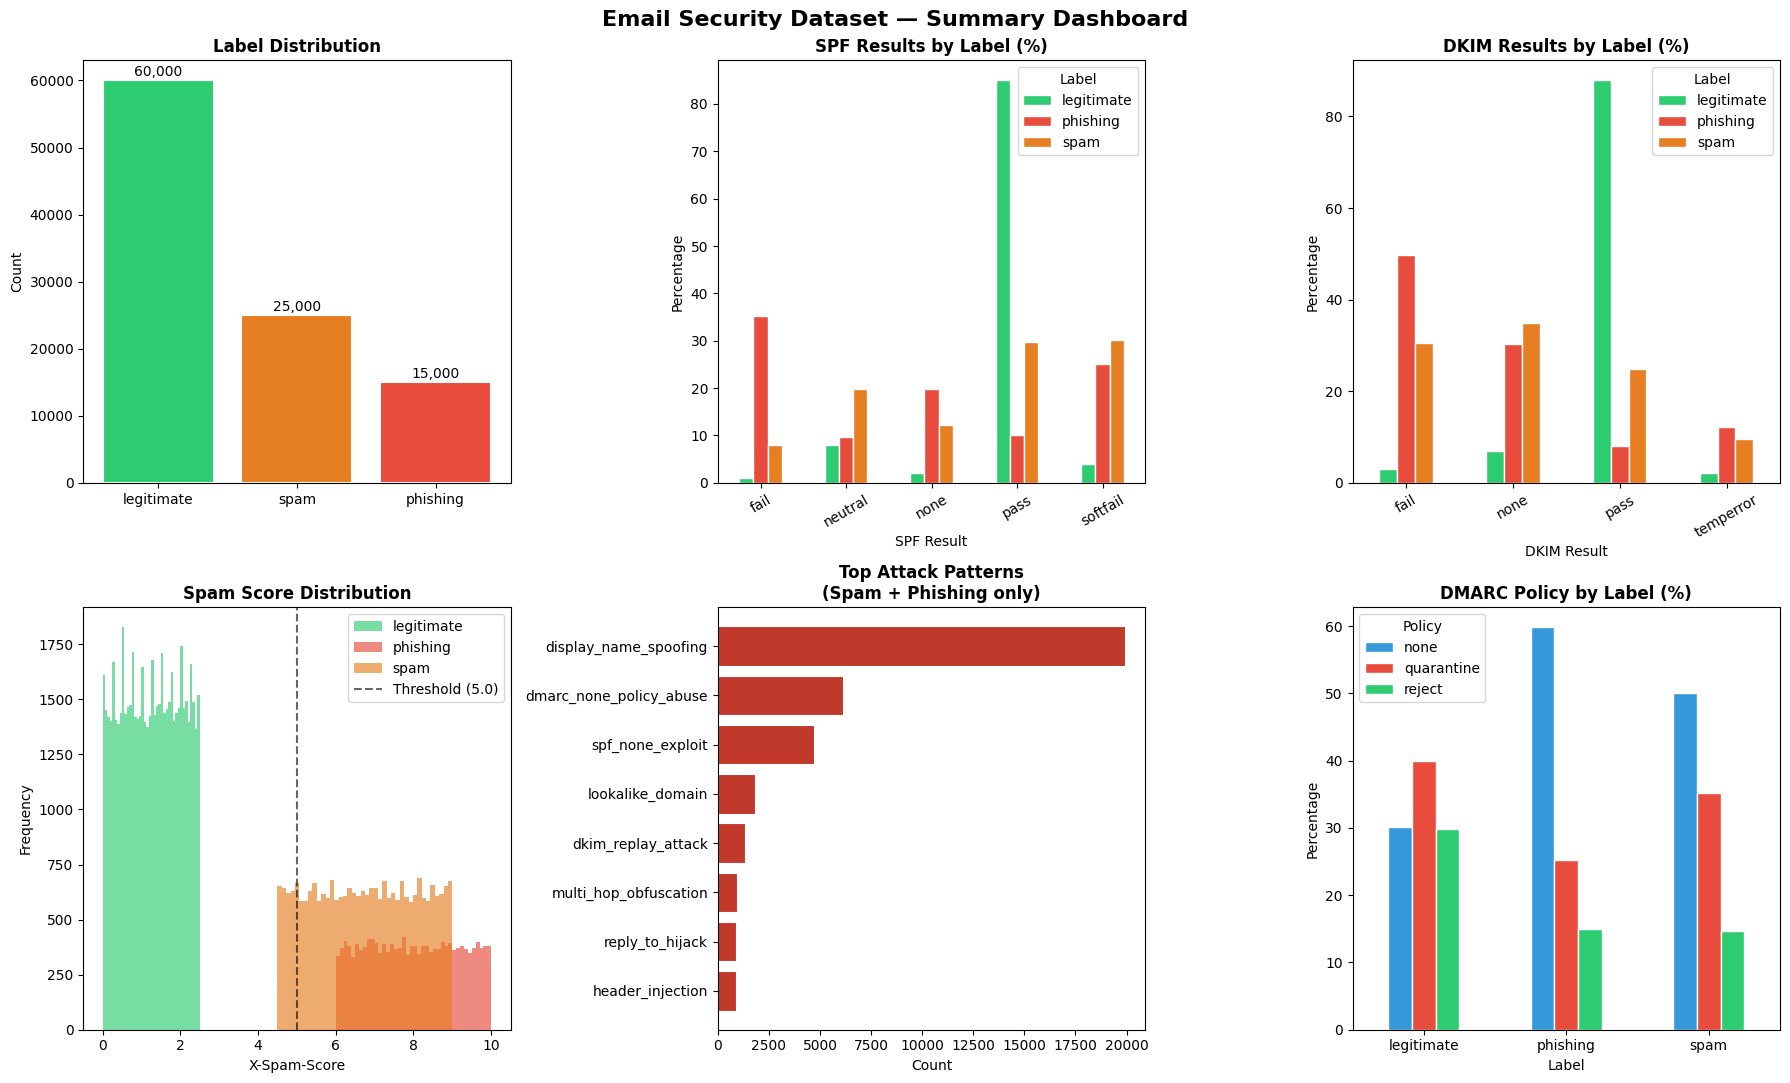

 Dashboard saved as email_security_dashboard.png


In [15]:

#  VISUALIZATIONS


fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Email Security Dataset — Summary Dashboard', fontsize=16, fontweight='bold')
colors = {'legitimate': '#2ecc71', 'spam': '#e67e22', 'phishing': '#e74c3c'}

# 1. Label Distribution
ax = axes[0, 0]
label_counts = df['label'].value_counts()
bars = ax.bar(label_counts.index,
              label_counts.values,
              color=[colors[l] for l in label_counts.index],
              edgecolor='white', linewidth=1.5)
ax.set_title('Label Distribution', fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

# 2. SPF Results by Label
ax = axes[0, 1]
spf_cross = pd.crosstab(df['label'], df['spf_result'], normalize='index') * 100
spf_cross.T.plot(kind='bar', ax=ax, color=[colors[c] for c in spf_cross.index],
                  edgecolor='white')
ax.set_title('SPF Results by Label (%)', fontweight='bold')
ax.set_xlabel('SPF Result')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Label')

# 3. DKIM Results by Label
ax = axes[0, 2]
dkim_cross = pd.crosstab(df['label'], df['dkim_result'], normalize='index') * 100
dkim_cross.T.plot(kind='bar', ax=ax, color=[colors[c] for c in dkim_cross.index],
                   edgecolor='white')
ax.set_title('DKIM Results by Label (%)', fontweight='bold')
ax.set_xlabel('DKIM Result')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Label')

# 4. Spam Score Distribution
ax = axes[1, 0]
for lbl, grp in df.groupby('label'):
    ax.hist(grp['x_spam_score'], bins=40, alpha=0.65,
            color=colors[lbl], label=lbl, edgecolor='none')
ax.axvline(x=5, color='black', linestyle='--', alpha=0.6, label='Threshold (5.0)')
ax.set_title('Spam Score Distribution', fontweight='bold')
ax.set_xlabel('X-Spam-Score')
ax.set_ylabel('Frequency')
ax.legend()

# 5. Attack Patterns
ax = axes[1, 1]
threat_df = df[df['label'] != 'legitimate']
ap_counts = threat_df['attack_pattern'].value_counts().head(8)
ax.barh(ap_counts.index, ap_counts.values,
         color='#c0392b', edgecolor='white', linewidth=0.8)
ax.set_title('Top Attack Patterns\n(Spam + Phishing only)', fontweight='bold')
ax.set_xlabel('Count')
ax.invert_yaxis()

# 6. DMARC Policy Distribution
ax = axes[1, 2]
dmarc_cross = pd.crosstab(df['label'], df['dmarc_policy'], normalize='index') * 100
dmarc_cross.plot(kind='bar', ax=ax, edgecolor='white',
                  color=['#3498db','#e74c3c','#2ecc71'])
ax.set_title('DMARC Policy by Label (%)', fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Policy')

plt.tight_layout()
plt.savefig('email_security_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dashboard saved as email_security_dashboard.png')

In [16]:

#  EXPORT RESEARCH SUBSETS


# 1. Security-focused features only (for ML model training)
ml_cols = [
    'spf_result', 'dkim_result', 'dmarc_result', 'dmarc_policy',
    'dmarc_alignment_spf', 'dmarc_alignment_dkim',
    'x_spam_score', 'hop_count', 'domain_alignment_match',
    'is_spoofed', 'attack_pattern', 'label'
]
df[ml_cols].to_csv('email_security_ml_features.csv', index=False)
print(' ML features subset saved → email_security_ml_features.csv')

# 2. Phishing-only dataset for phishing research
df[df['label']=='phishing'].to_csv('email_phishing_only.csv', index=False)
print(f' Phishing subset saved   → email_phishing_only.csv '
      f'({len(df[df["label"]=="phishing"]):,} records)')

# 3. Header-only view (raw header strings for NLP / parsing research)
header_cols = [
    'message_id', 'date', 'from', 'to', 'reply_to', 'subject',
    'return_path', 'received_chain', 'received_spf_raw',
    'dkim_signature_raw', 'authentication_results',
    'arc_seal', 'arc_message_signature', 'label'
]
df[header_cols].to_csv('email_raw_headers.csv', index=False)
print(' Raw headers subset saved → email_raw_headers.csv')

# 4. JSON export (first 1000 records as sample)
df.head(1000).to_json('email_security_sample_1k.json', orient='records', indent=2)
print(' JSON sample saved       → email_security_sample_1k.json')

print('\n All exports complete!')

 ML features subset saved → email_security_ml_features.csv
 Phishing subset saved   → email_phishing_only.csv (15,000 records)
 Raw headers subset saved → email_raw_headers.csv
 JSON sample saved       → email_security_sample_1k.json

 All exports complete!


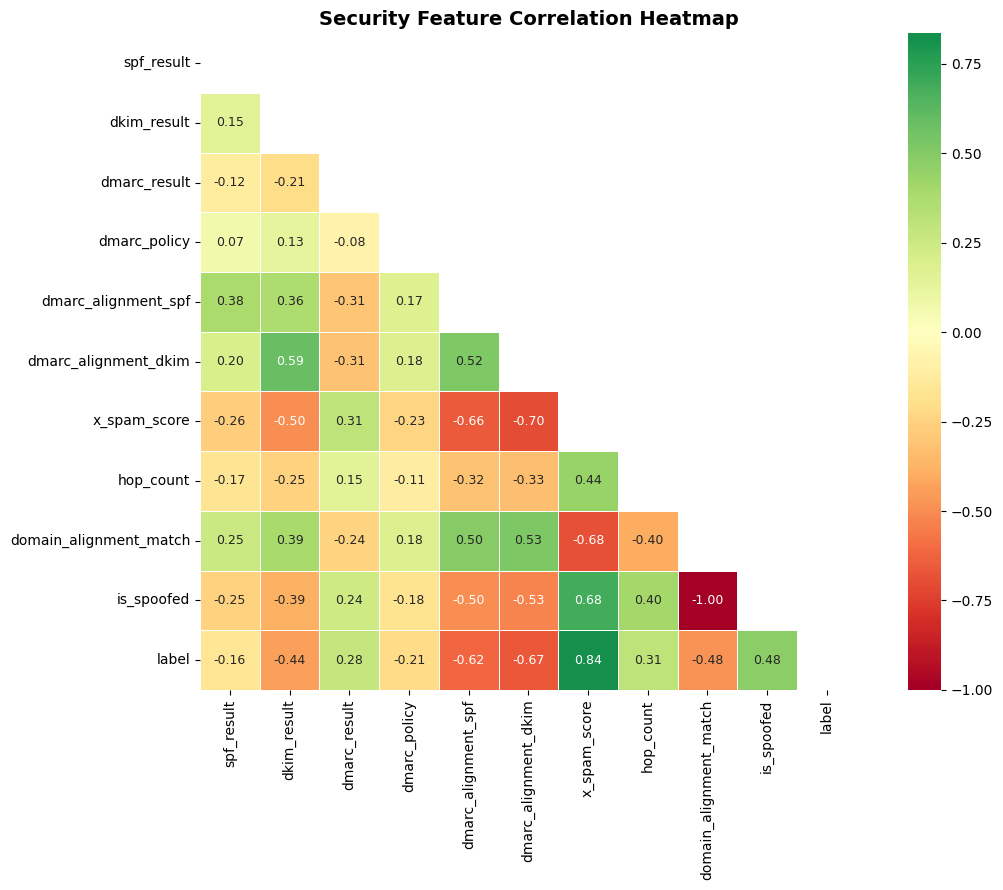

 Heatmap saved → email_security_correlation.png


In [17]:

#  CORRELATION HEATMAP FOR SECURITY FEATURES


from sklearn.preprocessing import LabelEncoder

encode_cols = [
    'spf_result', 'dkim_result', 'dmarc_result', 'dmarc_policy',
    'dmarc_alignment_spf', 'dmarc_alignment_dkim',
    'x_spam_score', 'hop_count', 'domain_alignment_match',
    'is_spoofed', 'label'
]

df_enc = df[encode_cols].copy()
le = LabelEncoder()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
df_enc['domain_alignment_match'] = df_enc['domain_alignment_match'].astype(int)
df_enc['is_spoofed']             = df_enc['is_spoofed'].astype(int)

plt.figure(figsize=(12, 9))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Security Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('email_security_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Heatmap saved → email_security_correlation.png')

In [18]:

#  FINAL SUMMARY


print('='*65)
print('  EMAIL SECURITY DATASET — GENERATION COMPLETE')
print('='*65)
print(f'  Total records      : {len(df):,}')
print(f'  Total features     : {len(df.columns)}')
print(f'  Legitimate emails  : {len(df[df["label"]=="legitimate"]):,}')
print(f'  Spam emails        : {len(df[df["label"]=="spam"]):,}')
print(f'  Phishing emails    : {len(df[df["label"]=="phishing"]):,}')
print('─'*65)
print('  Output files:')
files = [
    ('email_security_dataset.csv',      'Full dataset (all 100K records)'),
    ('email_security_ml_features.csv',  'ML-ready feature subset'),
    ('email_phishing_only.csv',         'Phishing records only'),
    ('email_raw_headers.csv',           'Raw header strings (NLP/parsing)'),
    ('email_security_sample_1k.json',   'JSON sample (1K records)'),
    ('email_security_dashboard.png',    'Summary dashboard chart'),
    ('email_security_correlation.png',  'Feature correlation heatmap'),
]
for fname, desc in files:
    size = os.path.getsize(fname) / 1024 if os.path.exists(fname) else 0
    print(f'   {fname:<40} {size:>8.1f} KB  — {desc}')
print('='*65)

  EMAIL SECURITY DATASET — GENERATION COMPLETE
  Total records      : 100,000
  Total features     : 39
  Legitimate emails  : 60,000
  Spam emails        : 25,000
  Phishing emails    : 15,000
─────────────────────────────────────────────────────────────────
  Output files:
   email_security_dataset.csv               187430.4 KB  — Full dataset (all 100K records)
   email_security_ml_features.csv             7238.9 KB  — ML-ready feature subset
   email_phishing_only.csv                   30340.7 KB  — Phishing records only
   email_raw_headers.csv                    152195.6 KB  — Raw header strings (NLP/parsing)
   email_security_sample_1k.json              2745.1 KB  — JSON sample (1K records)
   email_security_dashboard.png                191.2 KB  — Summary dashboard chart
   email_security_correlation.png              134.3 KB  — Feature correlation heatmap
